In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [1]:
import torch
import numpy as np
import pandas as pd
import cv2
import shapely

print("All packages loaded successfully")
print("Torch version:", torch.__version__)

All packages loaded successfully
Torch version: 2.8.0


In [1]:
import sys
!{sys.executable} model/OOD_dro_classifier.py

Loading OOD data...

Using environment column for DRO groups: disaster

Split sizes:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Train label distribution:
damage_label
no-damage       120576
major-damage     17327
minor-damage     17063
destroyed        11578
Name: count, dtype: int64

OOD validation label distribution:
damage_label
no-damage       37859
destroyed        6089
major-damage     2260
minor-damage      625
Name: count, dtype: int64

OOD hold label distribution:
damage_label
no-damage       38388
minor-damage     8428
destroyed        3558
major-damage     3029
Name: count, dtype: int64

Train environments:
['hurricane-harvey', 'hurricane-matthew', 'mexico-earthquake', 'palu-tsunami']

OOD validation environments:
['guatemala-volcano', 'hurricane-florence', 'midwest-flooding', 'santa-rosa-wildfire']

OOD hold environments:
['hurricane-michael', 'socal-fire']

Image overlap check:
OOD_train intersection OOD_val: 0
OOD_train in

Loaded rows: 267015
Seeds loaded: [42, 123, 999, 2024, 2025]
Rows per seed:
seed
42      53403
123     53403
999     53403
2024    53403
2025    53403
Name: count, dtype: int64

Pooled normalized confusion matrix:
              no-damage  minor-damage  major-damage  destroyed
no-damage         0.768         0.178         0.044      0.011
minor-damage      0.560         0.357         0.059      0.024
major-damage      0.455         0.376         0.107      0.062
destroyed         0.264         0.451         0.155      0.130


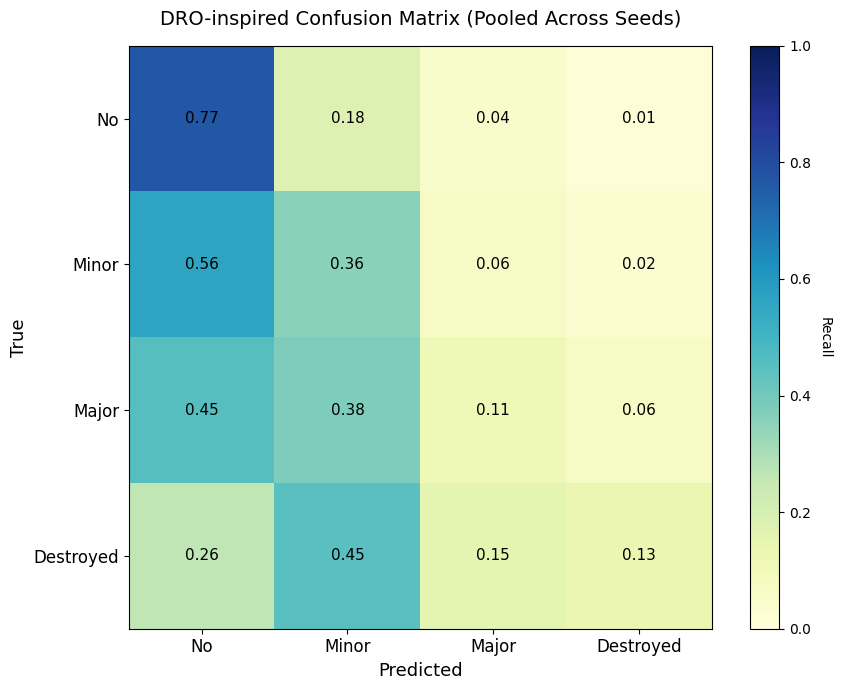

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

labels = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

short_labels = [
    "No",
    "Minor",
    "Major",
    "Destroyed",
]

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "baseline_resnet50_dro_unweighted_5seeds_1se"
)

# ============================================================
# Load all seed prediction files
# ============================================================

dfs = []

for seed in SEEDS:
    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(f"Missing prediction file: {pred_path}")

    df_seed = pd.read_csv(pred_path)
    df_seed["seed"] = seed
    dfs.append(df_seed)

df = pd.concat(dfs, ignore_index=True)

print("Loaded rows:", len(df))
print("Seeds loaded:", sorted(df["seed"].unique()))
print("Rows per seed:")
print(df["seed"].value_counts().sort_index())

# ============================================================
# True / predicted labels
# ============================================================

y_true = df["target_id"]
y_pred = df["pred_id"]

# ============================================================
# Overall pooled confusion matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

print("\nPooled normalized confusion matrix:")
print(pd.DataFrame(cm_norm, index=labels, columns=labels).round(3))

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    cm_norm,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
)

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Recall", rotation=270, labelpad=15)

ax.set_xticks(np.arange(len(short_labels)))
ax.set_yticks(np.arange(len(short_labels)))

ax.set_xticklabels(short_labels, fontsize=12)
ax.set_yticklabels(short_labels, fontsize=12)

ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("True", fontsize=13)

ax.set_title(
    "DRO-inspired Confusion Matrix (Pooled Across Seeds)",
    fontsize=14,
    pad=15,
)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="black",
        )

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score

root = Path(
    "/Users/paolo/Desktop/OOD_training_outputs/"
    "baseline_resnet50_dro_unweighted_5seeds_1se"
)

csv_files = sorted(root.glob("seed_*/ood_hold_predictions_selected_1se.csv"))

all_results = []

for file in csv_files:
    seed = int(file.parent.name.replace("seed_", ""))
    df = pd.read_csv(file)

    for env in sorted(df["disaster"].dropna().unique()):
        env_df = df[df["disaster"] == env]

        macro_f1 = f1_score(
            env_df["target_id"],
            env_df["pred_id"],
            average="macro",
            labels=[0, 1, 2, 3],
            zero_division=0
        )

        all_results.append({
            "seed": seed,
            "environment": env,
            "macro_f1": macro_f1
        })

results_df = pd.DataFrame(all_results)

summary = (
    results_df
    .groupby("environment")["macro_f1"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
    .sort_values("mean")
)

summary["se"] = summary["std"] / (summary["count"] ** 0.5)

print("\nDRO OOD HOLD environment summary:")
print(summary.round(4).to_string(index=False))

worst = summary.iloc[0]

print("\nWorst DRO OOD HOLD environment:")
print({
    "environment": worst["environment"],
    "macro_f1_mean": round(float(worst["mean"]), 4),
    "macro_f1_std": round(float(worst["std"]), 4),
    "macro_f1_min": round(float(worst["min"]), 4),
    "macro_f1_max": round(float(worst["max"]), 4),
    "num_seeds": int(worst["count"]),
    "macro_f1_se": round(float(worst["se"]), 4)
})


DRO OOD HOLD environment summary:
      environment   mean    std    min    max  count     se
       socal-fire 0.2751 0.0224 0.2413 0.2968      5 0.0100
hurricane-michael 0.3482 0.0194 0.3203 0.3675      5 0.0087

Worst DRO OOD HOLD environment:
{'environment': 'socal-fire', 'macro_f1_mean': 0.2751, 'macro_f1_std': 0.0224, 'macro_f1_min': 0.2413, 'macro_f1_max': 0.2968, 'num_seeds': 5, 'macro_f1_se': 0.01}


In [10]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

DISASTER_NAME = "hurricane-michael"

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "baseline_resnet50_dro_unweighted_5seeds_1se"
)

# ============================================================
# Load all seeds
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)

    df_seed["seed"] = seed

    dfs.append(df_seed)

# ============================================================
# Concatenate
# ============================================================

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

# ============================================================
# Filter disaster
# ============================================================

subset = df[df["disaster"] == DISASTER_NAME].copy()

print(f"\nSamples in {DISASTER_NAME}: {len(subset)}")

# ============================================================
# Macro F1
# ============================================================

macro_f1 = f1_score(
    subset["target_id"],
    subset["pred_id"],
    average="macro",
)

print(f"\nMacro F1 ({DISASTER_NAME}): {macro_f1:.4f}")

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        subset["target_id"],
        subset["pred_id"],
        digits=4,
        zero_division=0,
    )
)

# ============================================================
# Confusion matrix
# ============================================================

cm = confusion_matrix(
    subset["target_id"],
    subset["pred_id"],
    normalize="true",
)

print("\nNormalized Confusion Matrix:\n")

print(cm)


Loaded rows: 267015

Samples in hurricane-michael: 175635

Macro F1 (hurricane-michael): 0.3506

Classification Report:

              precision    recall  f1-score   support

           0     0.7249    0.7257    0.7253    113455
           1     0.3150    0.3591    0.3356     41460
           2     0.1514    0.1046    0.1237     14595
           3     0.2510    0.1925    0.2179      6125

    accuracy                         0.5690    175635
   macro avg     0.3606    0.3455    0.3506    175635
weighted avg     0.5639    0.5690    0.5656    175635


Normalized Confusion Matrix:

[[0.72573267 0.21342382 0.04684677 0.01399674]
 [0.55779064 0.35906898 0.05890014 0.02424023]
 [0.46118534 0.37074341 0.10462487 0.06344639]
 [0.22808163 0.44881633 0.13061224 0.1924898 ]]


In [12]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

DISASTER_NAME = "hurricane-florence"

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "baseline_resnet50_dro_unweighted_5seeds_1se"
)

class_names = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

# ============================================================
# Load OOD validation predictions across all seeds
# Florence is in OOD_test -> validation predictions
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_val_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)
    df_seed["seed"] = seed

    dfs.append(df_seed)

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

print("\nSeeds loaded:")
print(sorted(df["seed"].unique()))

print("\nAvailable disaster names:")
print(sorted(df["disaster"].astype(str).unique()))

# ============================================================
# Filter Florence
# ============================================================

subset = df[
    df["disaster"]
    .astype(str)
    .str.strip()
    .str.lower()
    == DISASTER_NAME.lower()
].copy()

print(f"\nSamples in {DISASTER_NAME}: {len(subset)}")

if len(subset) == 0:
    raise ValueError(
        f"No samples found for disaster: {DISASTER_NAME}"
    )

# ============================================================
# Macro F1
# ============================================================

macro_f1 = f1_score(
    subset["target_id"],
    subset["pred_id"],
    average="macro",
    labels=[0, 1, 2, 3],
    zero_division=0,
)

print(f"\nPooled Macro F1 ({DISASTER_NAME}): {macro_f1:.4f}")

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        subset["target_id"],
        subset["pred_id"],
        labels=[0, 1, 2, 3],
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

# ============================================================
# Normalized confusion matrix
# ============================================================

cm = confusion_matrix(
    subset["target_id"],
    subset["pred_id"],
    labels=[0, 1, 2, 3],
    normalize="true",
)

print("\nNormalized Confusion Matrix:\n")
print(cm)

# ============================================================
# Pretty DataFrame version
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion Matrix DataFrame:\n")
print(cm_df.round(3))


Loaded rows: 234165

Seeds loaded:
[42, 123, 999, 2024, 2025]

Available disaster names:
['guatemala-volcano', 'hurricane-florence', 'midwest-flooding', 'santa-rosa-wildfire']

Samples in hurricane-florence: 53640

Pooled Macro F1 (hurricane-florence): 0.2909

Classification Report:

              precision    recall  f1-score   support

   no-damage     0.8671    0.6176    0.7214     42330
minor-damage     0.0263    0.1845    0.0460      1160
major-damage     0.3109    0.4563    0.3698      9745
   destroyed     0.0181    0.0469    0.0262       405

    accuracy                         0.5746     53640
   macro avg     0.3056    0.3263    0.2909     53640
weighted avg     0.7415    0.5746    0.6377     53640


Normalized Confusion Matrix:

[[0.61762343 0.14349161 0.21974959 0.01913536]
 [0.47241379 0.18448276 0.32844828 0.01465517]
 [0.34273987 0.18019497 0.45633658 0.02072858]
 [0.29135802 0.2345679  0.42716049 0.04691358]]

Confusion Matrix DataFrame:

              no-damage  mino

Available splits:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Rows in selected split: 53403
Rows in prediction file: 53403

Number of available images: 1191

First available image IDs:
image_id
hurricane-michael_00000470    261
socal-fire_00000806           243
hurricane-michael_00000513    236
socal-fire_00000902           232
hurricane-michael_00000527    230
Name: count, dtype: int64

Selected image_id: hurricane-michael_00000003
Number of buildings in selected image: 35


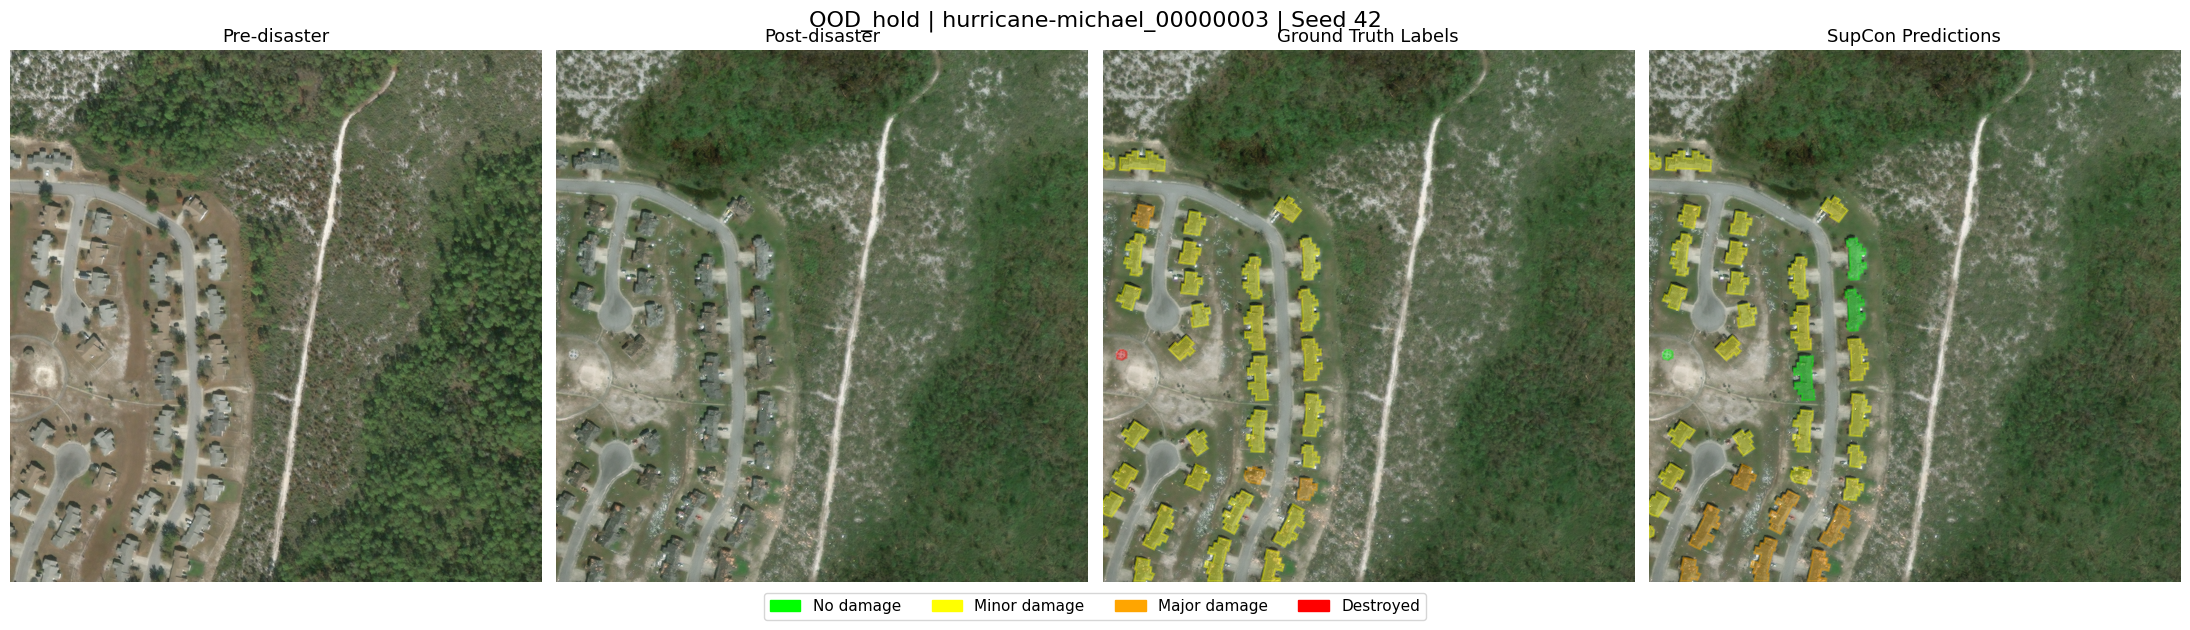

In [5]:
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

# =========================
# Configuration
# =========================

SEED = 42
CSV_SPLIT = "OOD_hold"

BASE_DIR = Path.home() / "Desktop"

CSV_PATH = (
    BASE_DIR
    / "OOD_processed"
    / "buildings_all_OOD_with_crops.csv"
)

OUTPUT_DIR = (
    BASE_DIR
    / "OOD_training_outputs"
    / "baseline_resnet50_dro_unweighted_5seeds_1se"
)

PRED_PATH = (
    OUTPUT_DIR
    / f"seed_{SEED}"
    / "ood_hold_predictions_selected_1se.csv"
)

LABELS = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

COLORS = {
    "no-damage": "lime",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
}

# =========================
# Load data
# =========================

df = pd.read_csv(CSV_PATH)
pred_df = pd.read_csv(PRED_PATH)

print("Available splits:")
print(df["split"].value_counts())

split_df = df[df["split"] == CSV_SPLIT].copy().reset_index(drop=True)

print("\nRows in selected split:", len(split_df))
print("Rows in prediction file:", len(pred_df))

if len(split_df) == 0:
    raise ValueError(f"No rows found for split: {CSV_SPLIT}")

if len(split_df) != len(pred_df):
    raise ValueError(
        f"Mismatch: CSV split has {len(split_df)} rows, "
        f"but prediction file has {len(pred_df)} rows."
    )

# =========================
# Add predictions
# =========================

split_df["pred_idx"] = pred_df["pred_id"].values
split_df["true_idx"] = pred_df["target_id"].values

split_df["pred_label"] = split_df["pred_idx"].map(lambda i: LABELS[int(i)])
split_df["true_label"] = split_df["true_idx"].map(lambda i: LABELS[int(i)])

# =========================
# Select image
# =========================

counts = split_df["image_id"].value_counts()

print("\nNumber of available images:", len(counts))
print("\nFirst available image IDs:")
print(counts.head())

IMAGE_INDEX = 520

if IMAGE_INDEX >= len(counts):
    raise ValueError(
        f"IMAGE_INDEX={IMAGE_INDEX} is too large. "
        f"Maximum valid index is {len(counts) - 1}."
    )

image_id = counts.index[IMAGE_INDEX]
img_df = split_df[split_df["image_id"] == image_id].copy()

print("\nSelected image_id:", image_id)
print("Number of buildings in selected image:", len(img_df))

# =========================
# Load images
# =========================

pre_path = Path(img_df.iloc[0]["pre_image_path"])
post_path = Path(img_df.iloc[0]["post_image_path"])

if not pre_path.exists():
    raise FileNotFoundError(f"Missing pre-disaster image: {pre_path}")

if not post_path.exists():
    raise FileNotFoundError(f"Missing post-disaster image: {post_path}")

pre = np.array(Image.open(pre_path))
post = np.array(Image.open(post_path))

# =========================
# Plotting helper
# =========================

def draw_polygons(ax, image, rows, label_col, title):
    ax.imshow(image)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

    for _, row in rows.iterrows():
        poly = wkt.loads(row["wkt"])
        label = row[label_col]
        color = COLORS[label]

        x, y = poly.exterior.xy
        coords = list(zip(x, y))

        patch = mpatches.Polygon(
            coords,
            closed=True,
            fill=True,
            alpha=0.35,
            edgecolor=color,
            facecolor=color,
            linewidth=1.5,
        )

        ax.add_patch(patch)

# =========================
# Legend
# =========================

legend_elements = [
    mpatches.Patch(color=COLORS["no-damage"], label="No damage"),
    mpatches.Patch(color=COLORS["minor-damage"], label="Minor damage"),
    mpatches.Patch(color=COLORS["major-damage"], label="Major damage"),
    mpatches.Patch(color=COLORS["destroyed"], label="Destroyed"),
]

# =========================
# Plot
# =========================

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(pre)
axes[0].set_title("Pre-disaster", fontsize=13)
axes[0].axis("off")

axes[1].imshow(post)
axes[1].set_title("Post-disaster", fontsize=13)
axes[1].axis("off")

draw_polygons(
    axes[2],
    post,
    img_df,
    label_col="true_label",
    title="Ground Truth Labels",
)

draw_polygons(
    axes[3],
    post,
    img_df,
    label_col="pred_label",
    title="SupCon Predictions",
)

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=11,
)

plt.suptitle(
    f"{CSV_SPLIT} | {image_id} | Seed {SEED}",
    fontsize=16,
)

plt.tight_layout()
plt.show()